In [1]:
import pandas as pd

train_df = pd.read_csv("../data/processed/train.csv")
val_df   = pd.read_csv("../data/processed/val.csv")
test_df  = pd.read_csv("../data/processed/test.csv")

print("Train:", train_df.shape)
print("Val:",   val_df.shape)
print("Test:",  test_df.shape)

train_df.head()

Train: (29358, 6)
Val: (6291, 6)
Test: (6291, 6)


,clean_text,label,brunet_w,proper_nouns_count,singular_words_count,entity_diversity
0,يتناول البحث ابعاد الامن الانساني القانون التو...,1,33.216682,38,42,0.815789
1,النص الشعري الذي يتميز بالقدره علي استخدام الم...,1,42.465845,45,55,0.933333
2,ملخص يتناول البحث موضوع الخلع وشروطه واثاره بي...,1,51.706150,68,83,0.794118
3,يتناول البحث التزام العون الاقتصادي بضروره الا...,1,65.364308,72,91,0.930556
4,تستكشف الورقه البحثيه مبدا افتراض البراءه القا...,1,34.768221,39,47,0.923077


In [2]:
feature_cols = ["brunet_w", "proper_nouns_count", "singular_words_count", "entity_diversity"]

X_train = train_df[feature_cols]
y_train = train_df["label"]

X_val = val_df[feature_cols]
y_val = val_df["label"]

X_test = test_df[feature_cols]
y_test = test_df["label"]

X_train.shape, X_val.shape, X_test.shape

((29358, 4), (6291, 4), (6291, 4))

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(n_estimators=150, random_state=42),
    "Linear SVM": LinearSVC()
}

val_results = []

trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    y_val_pred = model.predict(X_val)
    acc  = accuracy_score(y_val, y_val_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_val, y_val_pred, average="weighted")
    
    try:
        if hasattr(model, "predict_proba"):
            y_scores = model.predict_proba(X_val)[:, 1]
        else:
            y_scores = model.decision_function(X_val)
        auc = roc_auc_score(y_val, y_scores)
    except Exception:
        auc = None
    
    val_results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC_AUC": auc
    })

val_results_df = pd.DataFrame(val_results)
val_results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.824829,0.808011,0.824829,0.783851,0.765365
1,Random Forest,0.941504,0.943477,0.941504,0.942234,0.962472
2,Linear SVM,0.818948,0.802893,0.818948,0.768415,0.764118


In [4]:
best_row = val_results_df.sort_values(by="Accuracy", ascending=False).iloc[0]
best_model_name = best_row["Model"]

print("Best model selected based on Validation Accuracy:")
print(best_row)
best_model_name

Best model selected based on Validation Accuracy:
Model        Random Forest
Accuracy          0.941504
Precision         0.943477
Recall            0.941504
F1                0.942234
ROC_AUC           0.962472
Name: 1, dtype: object


'Random Forest'

In [5]:
import numpy as np

best_model = models[best_model_name]

X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

best_model.fit(X_train_val, y_train_val)

print("Best model retrained on Train + Val:", best_model_name)

Best model retrained on Train + Val: Random Forest


In [6]:
from sklearn.metrics import classification_report, confusion_matrix

y_test_pred = best_model.predict(X_test)
acc  = accuracy_score(y_test, y_test_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average="weighted")

try:
    if hasattr(best_model, "predict_proba"):
        y_scores = best_model.predict_proba(X_test)[:, 1]
    else:
        y_scores = best_model.decision_function(X_test)
    auc = roc_auc_score(y_test, y_scores)
except Exception:
    auc = None

print("Final Test Evaluation")
print("Best model:", best_model_name)
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)
print("ROC-AUC:", auc)

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

Final Test Evaluation
Best model: Random Forest
Accuracy: 0.9591479891909076
Precision: 0.9633013277505174
Recall: 0.9591479891909076
F1-score: 0.9601447993733924
ROC-AUC: 0.986245627822982

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.97      0.90      1258
           1       0.99      0.96      0.97      5033

    accuracy                           0.96      6291
   macro avg       0.92      0.96      0.94      6291
weighted avg       0.96      0.96      0.96      6291

Confusion Matrix:
[[1220   38]
 [ 219 4814]]



=== Confusion Matrix: Logistic Regression ===
[[ 254 1004]
 [ 118 4915]]


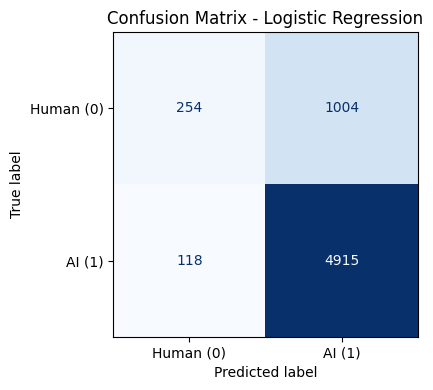


=== Confusion Matrix: Random Forest ===
[[1220   38]
 [ 219 4814]]


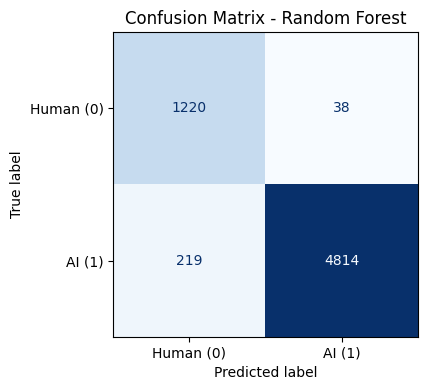


=== Confusion Matrix: Linear SVM ===
[[ 197 1061]
 [  78 4955]]


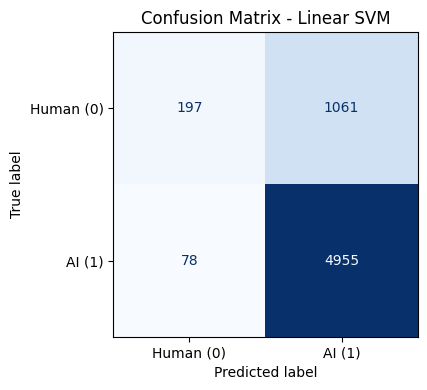

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for name, model in trained_models.items():
    print(f"\n=== Confusion Matrix: {name} ===")
    
    y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    print(cm)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=["Human (0)", "AI (1)"])
    
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()

In [8]:
test_with_preds = test_df.copy()
test_with_preds["y_true"] = y_test
test_with_preds["y_pred"] = y_test_pred

human_as_ai = test_with_preds[(test_with_preds["y_true"] == 0) & (test_with_preds["y_pred"] == 1)]
ai_as_human = test_with_preds[(test_with_preds["y_true"] == 1) & (test_with_preds["y_pred"] == 0)]

print("Human texts misclassified as AI:", human_as_ai.shape[0])
print("AI texts misclassified as Human:", ai_as_human.shape[0])

human_as_ai[["clean_text", "y_true", "y_pred"]].head(5)

Human texts misclassified as AI: 38
AI texts misclassified as Human: 219


,clean_text,y_true,y_pred
334,ان اقتحام المراه العربيه مختلف مجالات الثقافه ...,0,1
550,هتمت الدراسات النصيه الحديثه والقديمه باليه ال...,0,1
658,يحلل البحث الخطاب السياسي العراقي ويناقش امكان...,0,1
757,ان اقتحام المراه العربيه مختلف مجالات الثقافه ...,0,1
881,ادي التطور التكنولوجي الي ظهور العديد الاضرار ...,0,1


In [9]:
import joblib
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
model_dir = os.path.join(project_root, "model")
os.makedirs(model_dir, exist_ok=True)

best_model_name = val_results_df.sort_values("Accuracy", ascending=False).iloc[0]["Model"]
best_model = trained_models[best_model_name]

model_path = os.path.join(model_dir, f"{best_model_name.replace(' ', '_').lower()}_best_model.joblib")

joblib.dump(best_model, model_path)

print("Saved to:", model_path)
print("File exists? ", os.path.exists(model_path))

Saved to: /Users/m.abuselmi/PycharmProjects/MSIS822_Project/model/random_forest_best_model.joblib
File exists?  True
